In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
import numpy as np
import os

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
import zipfile
with zipfile.ZipFile("lfw250.zip", 'r') as zip_ref:
    zip_ref.extractall()
print("Extracted!")

Extracted!


In [25]:
import os
dataset_path = "lfw_250_classes/LFW_Peopels"
valid_people = []
for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)
    if not os.path.isdir(person_path):
        continue
    num_images = len(os.listdir(person_path))
    if num_images >= 20:
        valid_people.append(person)
print("Selected people:", valid_people[:5])
print("Total selected:", len(valid_people))

Selected people: ['Alejandro Toledo', 'Alvaro Uribe', 'Amelie Mauresmo', 'Andre Agassi', 'Angelina Jolie']
Total selected: 62


In [27]:
import os
import shutil
import random
source_dir = "lfw_250_classes/LFW_Peopels"
train_dir = "faces/train"
test_dir = "faces/test"
selected = valid_people[:5]
for person in selected:
    images = os.listdir(os.path.join(source_dir, person))
    random.shuffle(images)
    split = int(0.8 * len(images))
    train_imgs = images[:split]
    test_imgs = images[split:]
    os.makedirs(os.path.join(train_dir, person), exist_ok=True)
    os.makedirs(os.path.join(test_dir, person), exist_ok=True)
    for img in train_imgs:
        shutil.copy(os.path.join(source_dir, person, img),
                    os.path.join(train_dir, person, img))
    for img in test_imgs:
        shutil.copy(os.path.join(source_dir, person, img),
                    os.path.join(test_dir, person, img))
print("Dataset split done!")

Dataset split done!


In [29]:
for root, dirs, files in os.walk("faces"):
    print(root, "→", len(files))

faces → 0
faces\test → 0
faces\test\Alejandro Toledo → 8
faces\test\Alvaro Uribe → 7
faces\test\Amelie Mauresmo → 5
faces\test\Andre Agassi → 8
faces\test\Angelina Jolie → 4
faces\train → 0
faces\train\Alejandro Toledo → 31
faces\train\Alvaro Uribe → 28
faces\train\Amelie Mauresmo → 16
faces\train\Andre Agassi → 28
faces\train\Angelina Jolie → 16


In [31]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
train_data = datasets.ImageFolder("faces/train", transform=transform)
test_data = datasets.ImageFolder("faces/test", transform=transform)
print(train_data.classes)

['Alejandro Toledo', 'Alvaro Uribe', 'Amelie Mauresmo', 'Andre Agassi', 'Angelina Jolie']


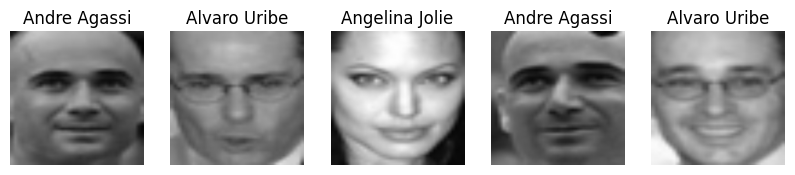

In [83]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.axis("off")
images, labels = next(iter(train_loader))
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    imshow(images[i])
    plt.title(train_data.classes[labels[i]])
plt.show()

In [65]:
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)
print("Model ready!")

Model ready!


In [95]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16)
loss_list = []
epochs = 50
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    loss_list.append(running_loss)
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 6.7549
Epoch 2, Loss: 6.5453
Epoch 3, Loss: 6.4623
Epoch 4, Loss: 6.3511
Epoch 5, Loss: 6.2512
Epoch 6, Loss: 6.2346
Epoch 7, Loss: 6.0949
Epoch 8, Loss: 6.0752
Epoch 9, Loss: 5.9014
Epoch 10, Loss: 5.8639
Epoch 11, Loss: 5.7065
Epoch 12, Loss: 5.7907
Epoch 13, Loss: 5.5852
Epoch 14, Loss: 5.4140
Epoch 15, Loss: 5.3639
Epoch 16, Loss: 5.3940
Epoch 17, Loss: 5.3536
Epoch 18, Loss: 5.2329
Epoch 19, Loss: 5.1607
Epoch 20, Loss: 5.0007
Epoch 21, Loss: 4.9727
Epoch 22, Loss: 4.9654
Epoch 23, Loss: 5.0094
Epoch 24, Loss: 4.8342
Epoch 25, Loss: 4.7717
Epoch 26, Loss: 4.6817
Epoch 27, Loss: 4.7057
Epoch 28, Loss: 4.4613
Epoch 29, Loss: 4.6338
Epoch 30, Loss: 4.4872
Epoch 31, Loss: 4.3944
Epoch 32, Loss: 4.2632
Epoch 33, Loss: 4.2339
Epoch 34, Loss: 4.1637
Epoch 35, Loss: 4.1096
Epoch 36, Loss: 4.1521
Epoch 37, Loss: 4.1554
Epoch 38, Loss: 4.0295
Epoch 39, Loss: 4.0062
Epoch 40, Loss: 4.0120
Epoch 41, Loss: 3.9491
Epoch 42, Loss: 3.9090
Epoch 43, Loss: 3.8128
Epoch 44, Loss: 3.83

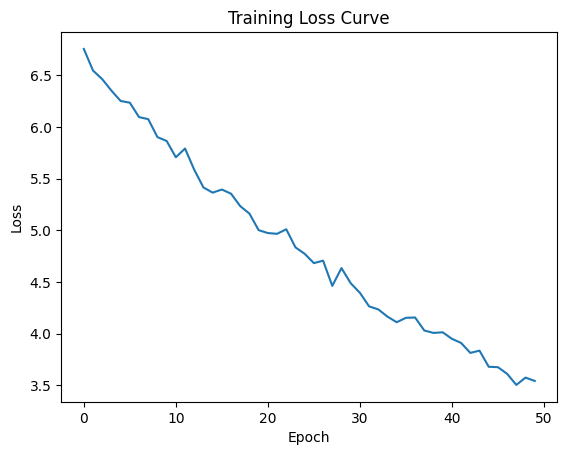

In [97]:
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [99]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)   
        correct += (preds == labels).sum().item()
print("Accuracy:", 100 * correct / total)

Accuracy: 87.5


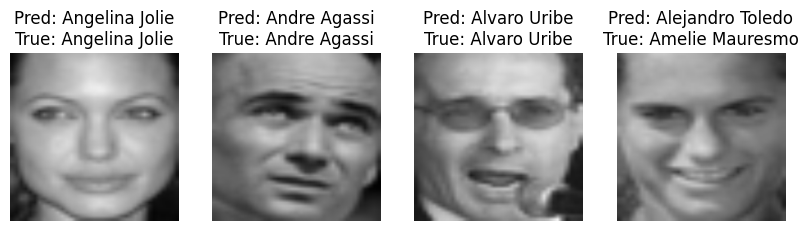

In [117]:
import random
plt.figure(figsize=(10,4))
classes = list(range(len(test_data.classes)))
selected_classes = random.sample(classes, 4)
for i, class_idx in enumerate(selected_classes):
    indices = [j for j, (_, label) in enumerate(test_data) if label == class_idx]
    idx = random.choice(indices)
    img, label = test_data[idx]
    input_img = img.unsqueeze(0).to(device)
    output = model(input_img)
    _, pred = torch.max(output, 1)
    plt.subplot(1,4,i+1)
    imshow(img)
    pred_name = train_data.classes[pred]
    true_name = train_data.classes[label]
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}")
plt.show()

In [119]:
from sklearn.metrics import confusion_matrix
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)

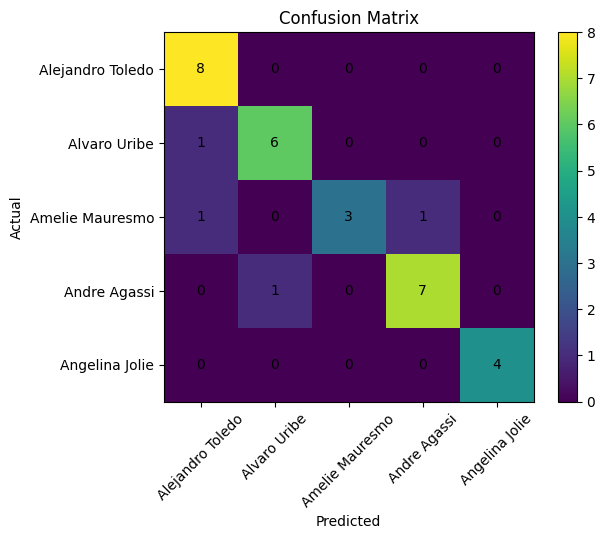

In [121]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
classes = train_data.classes
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i][j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()